# Домашнее задание 2. Компьютерный практикум 3.

Печенин Данила Михайлович. БПМ233.

In [137]:
import numpy as np
from numba import njit, prange, objmode
import matplotlib.pyplot as plt
import time

Note: 
Besides installation of these libraries better to install scipy, as numba seems to be needed this but don't automatically download it (at least on my laptop).  


In [138]:
@njit
def precompute_neighbors(Lx: int, Ly: int):
    """
    Precompute indices of right and bottom neighbors for all grid nodes.
    
    For each node (i, j) in the Lx × Ly grid, this function computes the indices
    of its right and bottom neighbors taking into account periodic boundary conditions.
    
    Parameters
    ----------
    Lx : int
        Number of nodes in the x-direction (horizontal size of the grid)
    Ly : int
        Number of nodes in the y-direction (vertical size of the grid)
    
    Returns
    -------
    right_neighbors : np.ndarray
        Array of shape (Lx, Ly, 2) containing indices of right neighbors.
        right_neighbors[i, j] = [i_right, j_right] where:
        - i_right = (i + 1) % Lx (periodic boundary in x-direction)
        - j_right = j (same row)
    bottom_neighbors : np.ndarray
        Array of shape (Lx, Ly, 2) containing indices of bottom neighbors.
        bottom_neighbors[i, j] = [i_bottom, j_bottom] where:
        - i_bottom = i (same column)
        - j_bottom = (j + 1) % Ly (periodic boundary in y-direction)
    """
    right_neighbors = np.zeros((Lx, Ly, 2), dtype=np.int32)
    bottom_neighbors = np.zeros((Lx, Ly, 2), dtype=np.int32)
    
    for i in range(Lx):
        for j in range(Ly):
            right_neighbors[i, j, 0] = (i + 1) % Lx
            right_neighbors[i, j, 1] = j
            
            bottom_neighbors[i, j, 0] = i
            bottom_neighbors[i, j, 1] = (j + 1) % Ly
    
    return right_neighbors, bottom_neighbors

In [ ]:
@njit(parallel=True)
def compute_normed_mean_energy(Lx_array: np.ndarray, Ly: int, kT_array: np.ndarray, J: float = 1.0) -> np.ndarray:
    """
    Compute the normalized mean energy per site for the 2D Ising model. This function provides exact solution.
    
    This function calculates the average energy per spin site for a 2D Ising model
    with periodic boundary conditions using exact enumeration of all possible
    spin configurations.
    
    The Ising model Hamiltonian with nearest-neighbor interactions is:
        H = -J * Σ_{<i,j>} σ_i σ_j
    where σ_i ∈ {-1, +1} are spin variables and the sum is over nearest neighbors.
    
    Parameters
    ----------
    Lx_array : np.ndarray
        1D array of integer values representing the horizontal sizes of the gird.
        Each element specifies the number of spins along the x-direction.
    Ly : int
        Integer value representing the vertical size of the gird (fixed for all computations).
        Specifies the number of spins along the y-direction.
    kT_array : np.ndarray
        1D array of float values representing temperature values multiplied by 
        Boltzmann's constant (k*T).
    J : float, optional
        Coupling constant between neighboring spins. Default is 1.0 (ferromagnetic coupling).
    
    Returns
    -------
    normed_mean_energies : np.ndarray
        2D array of shape (len(Lx_array), len(kT_array)) containing the normalized
        mean energy per site ⟨E⟩/(Lx*Ly) for each combination of gird size and temperature.
        The array is organized such that normed_mean_energies[i, j] corresponds to
        Lx_array[i] and kT_array[j].
    
    See Also
    --------
    precompute_neighbors : Function that precomputes neighbor indices for efficiency.
    """
    Lx_array_len, kT_array_len = Lx_array.shape[0], kT_array.shape[0]
    normed_mean_energies = np.zeros((Lx_array_len, kT_array_len))
    
    for Lx_idx in range(Lx_array_len):
        with objmode(start='f8'):
            start = time.time()

        Lx = Lx_array[Lx_idx]
        area = Lx * Ly
        states_len = 2 ** area
        right_neighbors, bottom_neighbors = precompute_neighbors(Lx, Ly)
        half_states = states_len // 2
        
        if half_states <= 10000:
            BLOCK_SIZE = half_states
        elif half_states <= 100000:
            BLOCK_SIZE = 10000
        elif half_states <= 1000000:
            BLOCK_SIZE = 50000
        else:
            BLOCK_SIZE = 100000 
        num_blocks = (half_states + BLOCK_SIZE - 1) // BLOCK_SIZE
        
        Z_blocks = np.zeros((num_blocks, kT_array_len))
        energy_sum_blocks = np.zeros((num_blocks, kT_array_len))
        
        for block_idx in prange(num_blocks):
            start_state = block_idx * BLOCK_SIZE
            end_state = min((block_idx + 1) * BLOCK_SIZE, half_states)
            
            for state in range(start_state, end_state):
                E = 0.0
                for i in range(area):
                    spin_i = ((state >> i) & 1) * 2 - 1
                    x_i = i // Ly
                    y_i = i % Ly
                    
                    x_right, y_right = right_neighbors[x_i, y_i]
                    idx_right = x_right * Ly + y_right
                    spin_right = ((state >> idx_right) & 1) * 2 - 1
                    E -= J * spin_i * spin_right
                    
                    x_bottom, y_bottom = bottom_neighbors[x_i, y_i]
                    idx_bottom = x_bottom * Ly + y_bottom
                    spin_bottom = ((state >> idx_bottom) & 1) * 2 - 1
                    E -= J * spin_i * spin_bottom
                
                for kT_idx in range(kT_array_len):
                    kT = kT_array[kT_idx]
                    if kT > 0:
                        weight = 2.0 * np.exp(-E / kT)
                        Z_blocks[block_idx, kT_idx] += weight
                        energy_sum_blocks[block_idx, kT_idx] += E * weight
        
        Z_total = np.sum(Z_blocks, axis=0)
        energy_sum_total = np.sum(energy_sum_blocks, axis=0)
        
        inv_area = 1.0 / area
        for kT_idx in range(kT_array_len):
            if Z_total[kT_idx] > 0:
                normed_mean_energies[Lx_idx, kT_idx] = energy_sum_total[kT_idx] / Z_total[kT_idx] * inv_area

        with objmode():
            print("Lx =", Lx, "done in", round(time.time() - start, 4), "seconds")

    return normed_mean_energies

In [140]:
Lx_array = np.arange(2, 18).astype(int)
kT_array = np.arange(1.0, 10.0, 0.2)
Ly = 2

start_time = time.time()
results = compute_normed_mean_energy(Lx_array, Ly, kT_array)
full_time = time.time() - start_time 
np.save("normed_mean_energy.npy", results)

Lx = 2 done in 0.0009 seconds
Lx = 3 done in 0.0002 seconds
Lx = 4 done in 0.0001 seconds
Lx = 5 done in 0.0002 seconds
Lx = 6 done in 0.0004 seconds
Lx = 7 done in 0.001 seconds
Lx = 8 done in 0.0014 seconds
Lx = 9 done in 0.007 seconds
Lx = 10 done in 0.014 seconds
Lx = 11 done in 0.0529 seconds
Lx = 12 done in 0.2149 seconds
Lx = 13 done in 0.8426 seconds
Lx = 14 done in 3.4543 seconds
Lx = 15 done in 14.5694 seconds
Lx = 16 done in 66.055 seconds
Lx = 17 done in 259.7376 seconds


In [141]:
print(f"Full time spent: {full_time:.4f}")

Full time spent: 345.7011


In [142]:
saved_result = np.load("normed_mean_energy.npy")

In [145]:
for i in range(len(Lx_array)):
    print(f"Lx = {Lx_array[i]}: ", saved_result[i])

Lx = 2:  [-1.99598209 -1.98483772 -1.96114384 -1.92211527 -1.86785426 -1.80082536
 -1.72475185 -1.6435674  -1.56072701 -1.47890165 -1.39994653 -1.32501373
 -1.2547137  -1.18927202 -1.12865902 -1.07268721 -1.02108034 -0.97351979
 -0.92967447 -0.88921917 -0.85184512 -0.81726544 -0.78521735 -0.75546244
 -0.72778573 -0.70199418 -0.67791481 -0.65539287 -0.63428991 -0.61448208
 -0.59585849 -0.57831975 -0.56177666 -0.54614905 -0.53136477 -0.51735872
 -0.50407213 -0.4914518  -0.4794495  -0.46802143 -0.45712773 -0.44673208
 -0.43680131 -0.4273051  -0.41821565]
Lx = 3:  [-1.99582582 -1.98371777 -1.95670686 -1.91012278 -1.84296444 -1.75812762
 -1.66111938 -1.55819814 -1.4548808  -1.35521516 -1.26170654 -1.17559625
 -1.09723746 -1.02643108 -0.96267565 -0.90533357 -0.85373236 -0.80722134
 -0.76519996 -0.7271291  -0.69253297 -0.66099579 -0.6321564  -0.60570195
 -0.58136171 -0.55890126 -0.53811739 -0.51883357 -0.50089605 -0.4841706
 -0.46853966 -0.45389999 -0.44016061 -0.42724114 -0.41507032 -0.40358

Check results: correct result (from the task) are in correct_result.txt, ours relusts should be the same.

In [157]:
with open('correct_results.txt', 'r') as f:
    correct_data = eval(f.read())

correct_data = np.array(correct_data)
np.allclose(saved_result, correct_data, atol=1e-8, rtol=0)

True

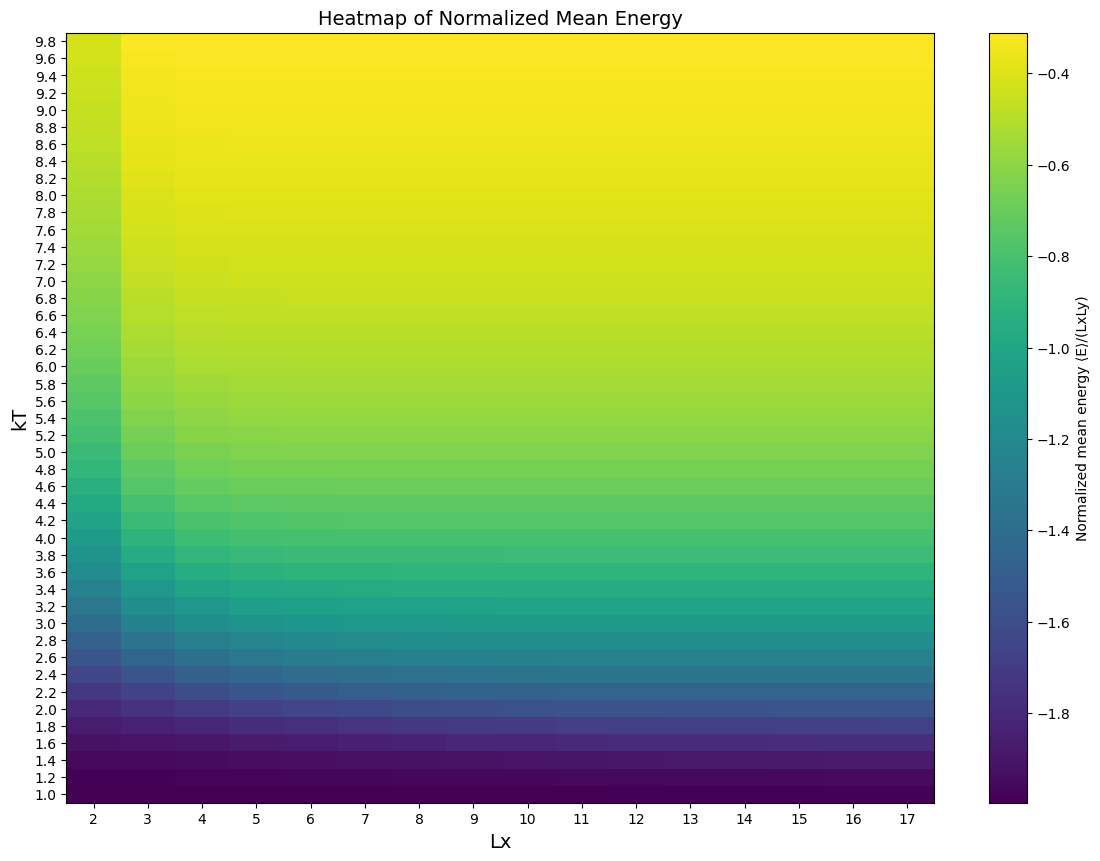

In [179]:
plt.figure(figsize=(14, 10))
plt.pcolormesh(Lx_array, kT_array, saved_result.T, shading='auto')
plt.xlabel('Lx', fontsize=14)
plt.ylabel('kT', fontsize=14)
plt.xticks(Lx_array)
plt.yticks(kT_array)
plt.colorbar(label='Normalized mean energy ⟨E⟩/(LxLy)')
plt.title('Heatmap of Normalized Mean Energy', fontsize=14)
plt.show()

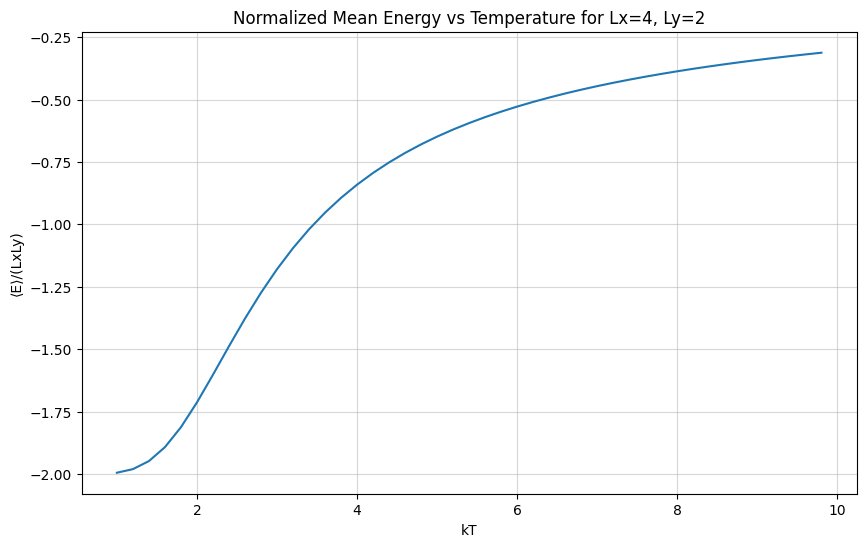

In [180]:
plt.figure(figsize=(10, 6))
plt.plot(kT_array, saved_result[2])
plt.xlabel('kT')
plt.ylabel('⟨E⟩/(LxLy)')
plt.title(f'Normalized Mean Energy vs Temperature for Lx={Lx_array[2]}, Ly={Ly}')
plt.grid(True, alpha=0.5)
plt.show()